In [7]:
import pandas as pd
import random
import numpy as np

# 1. THE MASTER SEEDS (15 Nepal, 30 International)
data_seeds = {
    "Nepal": [
        ("Kathmandu", 27.7172, 85.3240, 3500, "temple", ["culture", "history", "spiritual"]),
        ("Pokhara", 28.2333, 83.9844, 4500, "lake", ["nature", "adventure", "paragliding"]),
        ("Mustang", 28.9985, 83.8473, 9500, "himalayas", ["desert", "trekking", "mystical"]),
        ("Chitwan", 27.5341, 84.4525, 5500, "jungle", ["wildlife", "safari", "nature"]),
        ("Lumbini", 27.4839, 83.2759, 3000, "buddha", ["peace", "meditation", "zen"]),
        ("Namche", 27.8069, 86.7140, 12500, "everest", ["extreme", "climbing", "hiking"]),
        ("Rara", 29.5283, 82.0872, 8000, "rara-lake", ["serene", "hidden", "nature"]),
        ("Ilam", 26.9107, 87.9331, 3200, "tea-garden", ["greenery", "calm", "hills"]),
        ("Janakpur", 26.7271, 85.9221, 2800, "mithila", ["pilgrimage", "art", "tradition"]),
        ("Manang", 28.6667, 84.0167, 7000, "tilicho", ["rugged", "adventure", "mountain"]),
        # 5 NEW NEPAL PLACES
        ("Bandipur", 27.9333, 84.4167, 3800, "village", ["vintage", "culture", "quiet"]),
        ("Nagarkot", 27.7174, 85.5214, 4200, "sunrise", ["viewpoint", "nature", "relaxation"]),
        ("Gorkha", 28.0000, 84.6333, 3000, "palace", ["history", "warrior", "fort"]),
        ("Dharan", 26.8125, 87.2834, 3300, "hills", ["food", "vibrant", "hiking"]),
        ("Bardiya", 28.4684, 81.3320, 6000, "tiger", ["wildlife", "remote", "safari"])
    ],
    "International": [
        ("Paris", 48.8566, 2.3522, 25000, "paris", ["luxury", "romantic", "fashion"]),
        ("Bali", -8.3405, 115.0920, 9000, "ubud", ["beach", "tropical", "spiritual"]),
        ("Tokyo", 35.6762, 139.6503, 20000, "shibuya", ["modern", "anime", "food"]),
        ("Santorini", 36.3932, 25.4615, 38000, "oia", ["sunset", "villas", "romantic"]),
        ("Dubai", 25.2048, 55.2708, 48000, "burjkhalifa", ["luxury", "skyscraper", "wealth"]),
        ("London", 51.5074, -0.1278, 30000, "bigben", ["history", "urban", "museums"]),
        ("Singapore", 1.3521, 103.8198, 32000, "marina-bay", ["clean", "tech", "modern"]),
        ("New York", 40.7128, -74.0060, 42000, "manhattan", ["fast-paced", "city", "shopping"]),
        ("Bangkok", 13.7563, 100.5018, 7500, "streetfood", ["vibrant", "budget", "nightlife"]),
        ("Rome", 41.9028, 12.4964, 28000, "colosseum", ["ancient", "art", "culinary"]),
        # 20 NEW INTERNATIONAL PLACES
        ("Interlaken", 46.6863, 7.8632, 45000, "switzerland", ["nature", "luxury", "snow"]),
        ("Barcelona", 41.3851, 2.1734, 26000, "gaudi", ["art", "beach", "vibe"]),
        ("Amsterdam", 52.3676, 4.9041, 29000, "canals", ["canal", "urban", "history"]),
        ("Venice", 45.4408, 12.3155, 32000, "gondola", ["water", "romantic", "ancient"]),
        ("Maldives", 3.2028, 73.2207, 55000, "resort", ["luxury", "ocean", "privacy"]),
        ("Cairo", 30.0444, 31.2357, 8000, "pyramids", ["ancient", "history", "mystical"]),
        ("Istanbul", 41.0082, 28.9784, 12000, "mosque", ["culture", "food", "bridge"]),
        ("Sydney", -33.8688, 151.2093, 31000, "opera-house", ["modern", "harbor", "coastal"]),
        ("Rio", -22.9068, -43.1729, 15000, "christ-redeemer", ["vibrant", "nature", "carnival"]),
        ("Kyoto", 35.0116, 135.7681, 19000, "shrine", ["zen", "ancient", "tradition"]),
        ("Cape Town", -33.9249, 18.4241, 14000, "table-mountain", ["nature", "adventure", "ocean"]),
        ("Prague", 50.0755, 14.4378, 18000, "oldtown", ["gothic", "history", "fairytale"]),
        ("Seoul", 37.5665, 126.9780, 22000, "kpop", ["tech", "food", "modern"]),
        ("Machu Picchu", -13.1631, -72.5450, 16000, "peru", ["ancient", "adventure", "hiking"]),
        ("Marrakech", 31.6295, -7.9811, 9000, "souk", ["market", "exotic", "culture"]),
        ("Florence", 43.7696, 11.2558, 27000, "renaissance", ["art", "culture", "museum"]),
        ("Berlin", 52.5200, 13.4050, 24000, "brandenburg-gate", ["history", "urban", "tech"]),
        ("Lisbon", 38.7223, -9.1393, 20000, "tram", ["coastal", "vibe", "old-world"]),
        ("Edinburgh", 55.9533, -3.1883, 26000, "castle", ["history", "nature", "gothic"]),
        ("Amalfi", 40.6333, 14.6027, 40000, "italy-coast", ["scenic", "luxury", "ocean"])
    ]
}

def generate_100k_balanced_dataset(target_rows=100000):
    data = []
    suffixes = ["Heights", "Lakeside", "Valley", "Viewpoint", "District", "Market", "Resort", "Plaza"]
    
    print(f" Generating {target_rows} balanced records for 45 destinations...")

    for i in range(1, target_rows + 1):
        # EXACT BALANCE: 50% Nepal, 50% International
        region_key = "Nepal" if i % 2 == 0 else "International"
        
        base_city, base_lat, base_lon, base_cost, img_kw, vibes_pool = random.choice(data_seeds[region_key])
        
        # 1. Procedural Variation
        city_name = f"{base_city} {random.choice(suffixes)} {i}"
        lat = round(base_lat + random.uniform(-0.05, 0.05), 5)
        lon = round(base_lon + random.uniform(-0.05, 0.05), 5)
        
        # 2. Vibe & Tiering
        tags = random.sample(vibes_pool, 2)
        style = random.choice(["budget", "mid-range", "luxury"])
        tags.append(style)
        vibe_tags = ", ".join(tags)
        
        # 3. Calculated Base Cost
        cost = int(base_cost * random.uniform(0.9, 1.1))
        description = f"Experience the {tags[0]} allure of {city_name} in {region_key}."
        image_url = f"https://loremflickr.com/800/600/{img_kw}?lock={i}"

        data.append([i, city_name, region_key, vibe_tags, description, cost, lat, lon, image_url])

    df = pd.DataFrame(data, columns=['id', 'city', 'country', 'vibe_tags', 'description', 'avg_cost_per_day_npr', 'latitude', 'longitude', 'image_url'])
    df.to_csv('../destinations.csv', index=False)
    print(" Balanced 100k dataset saved.")

generate_100k_balanced_dataset(100000)

 Generating 100000 balanced records for 45 destinations...
 Balanced 100k dataset saved.


# Loading Dataset

In [12]:
df = pd.read_csv('../destinations.csv')
df.head(10)

,id,city,country,vibe_tags,description,avg_cost_per_day_npr,latitude,longitude,image_url
0,1,Cairo Resort 1,International,"history, mystical, mid-range",Experience the history allure of Cairo Resort ...,8723,30.08034,31.23901,https://loremflickr.com/800/600/pyramids?lock=1
1,2,Pokhara District 2,Nepal,"paragliding, adventure, mid-range",Experience the paragliding allure of Pokhara D...,4758,28.19218,83.98591,https://loremflickr.com/800/600/lake?lock=2
2,3,Cape Town Plaza 3,International,"nature, adventure, budget",Experience the nature allure of Cape Town Plaz...,12746,-33.88954,18.43757,https://loremflickr.com/800/600/table-mountain...
3,4,Manang Lakeside 4,Nepal,"mountain, rugged, luxury",Experience the mountain allure of Manang Lakes...,7538,28.66962,83.96876,https://loremflickr.com/800/600/tilicho?lock=4
4,5,Rio Market 5,International,"carnival, nature, mid-range",Experience the carnival allure of Rio Market 5...,15839,-22.95418,-43.20618,https://loremflickr.com/800/600/christ-redeeme...
5,6,Nagarkot Heights 6,Nepal,"relaxation, nature, budget",Experience the relaxation allure of Nagarkot H...,3809,27.75422,85.52707,https://loremflickr.com/800/600/sunrise?lock=6
6,7,Paris Valley 7,International,"romantic, fashion, budget",Experience the romantic allure of Paris Valley...,25554,48.84939,2.36026,https://loremflickr.com/800/600/paris?lock=7
7,8,Janakpur Valley 8,Nepal,"pilgrimage, art, luxury",Experience the pilgrimage allure of Janakpur V...,2795,26.71023,85.92888,https://loremflickr.com/800/600/mithila?lock=8
8,9,Venice Lakeside 9,International,"romantic, water, mid-range",Experience the romantic allure of Venice Lakes...,32802,45.41841,12.26845,https://loremflickr.com/800/600/gondola?lock=9
9,10,Mustang Viewpoint 10,Nepal,"mystical, desert, mid-range",Experience the mystical allure of Mustang View...,9681,29.02300,83.85426,https://loremflickr.com/800/600/himalayas?lock=10


# Data Cleaning

In [15]:
# 1. Remove duplicates
df = df.drop_duplicates()

# 2. Handle missing values
df['vibe_tags'] = df['vibe_tags'].fillna('general')
df['description'] = df['description'].fillna('Explore this beautiful destination.')

# 3. Standardize text for NLP
df['vibe_tags'] = df['vibe_tags'].str.lower().str.strip()

# 4. Outlier Removal (Functional Step)
# Ensure no costs are less than 500 NPR or greater than 100,000 per day
df = df[(df['avg_cost_per_day_npr'] >= 500) & (df['avg_cost_per_day_npr'] <= 100000)]

print(f" Data Cleaned. {len(df)} rows ready.")

 Data Cleaned. 100000 rows ready.


# EDA

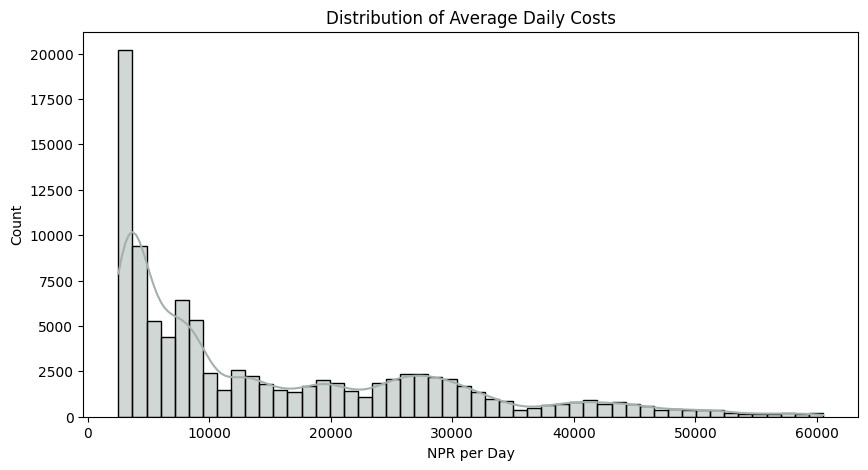

In [17]:
import seaborn as sns
# 1. Distribution of Daily Costs (Is the data varied?)
plt.figure(figsize=(10, 5))
sns.histplot(df['avg_cost_per_day_npr'], bins=50, kde=True, color='#A3B1AA')
plt.title('Distribution of Average Daily Costs')
plt.xlabel('NPR per Day')
plt.show()

C:\Users\ASUS1\AppData\Local\Temp\ipykernel_19792\4010393475.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='country', data=df, palette=['#2D1B10', '#A3B1AA'])


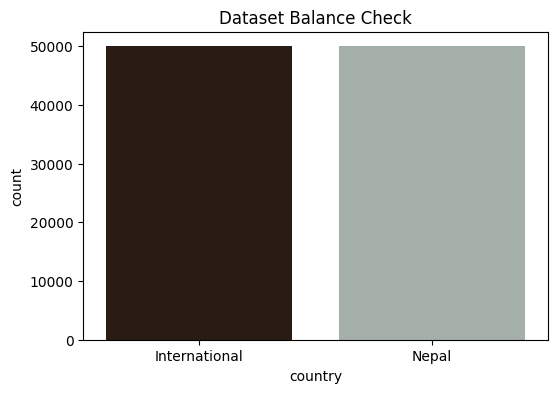

In [18]:
# 2. Nepal vs International Balance (Proves no class imbalance)
plt.figure(figsize=(6, 4))
sns.countplot(x='country', data=df, palette=['#2D1B10', '#A3B1AA'])
plt.title('Dataset Balance Check')
plt.show()

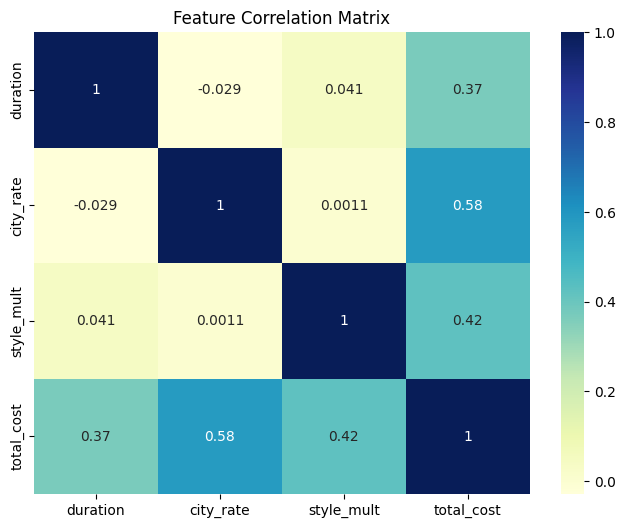

In [20]:
# 3. Correlation Heatmap (Proves features are mathematically related)
# Note: We simulate a small regression dataframe first to show correlations
test_reg = pd.DataFrame({
    'duration': [random.randint(1,15) for _ in range(1000)],
    'city_rate': [random.choice(df['avg_cost_per_day_npr'].values) for _ in range(1000)],
    'style_mult': [random.choice([0.7, 1.0, 2.8]) for _ in range(1000)]
})
test_reg['total_cost'] = (test_reg['duration'] * test_reg['city_rate'] * test_reg['style_mult'])
plt.figure(figsize=(8, 6))
sns.heatmap(test_reg.corr(), annot=True, cmap='YlGnBu')
plt.title('Feature Correlation Matrix')
plt.show()

C:\Users\ASUS1\AppData\Local\Temp\ipykernel_19792\895332110.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


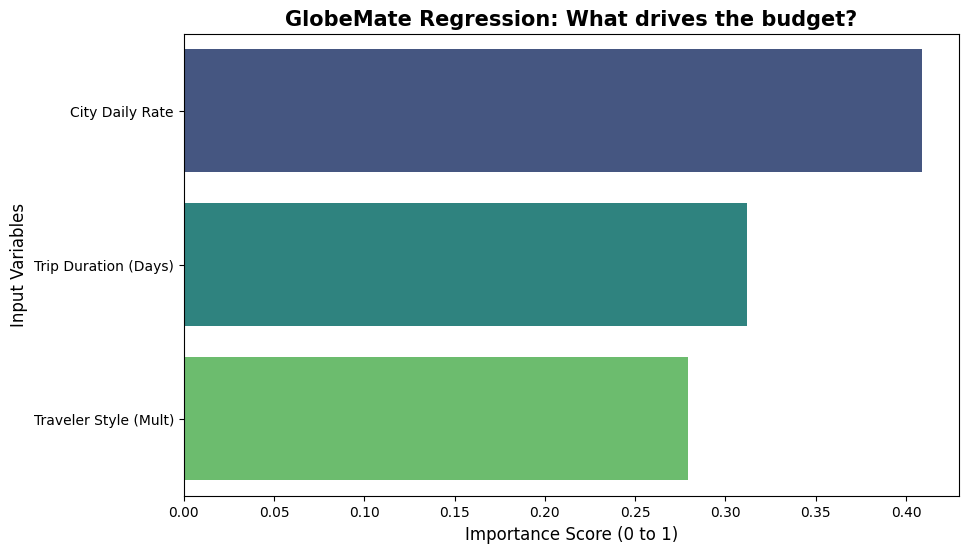

In [35]:
# 1. Extract the importance scores from your trained model
importances = budget_model.feature_importances_
feature_names = ['Trip Duration (Days)', 'City Daily Rate', 'Traveler Style (Mult)']

# 2. Create a clean DataFrame for plotting
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# 3. Create the professional Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')

plt.title('GlobeMate Regression: What drives the budget?', fontsize=15, fontweight='bold')
plt.xlabel('Importance Score (0 to 1)', fontsize=12)
plt.ylabel('Input Variables', fontsize=12)

# Save this for Chapter 5 of your report!
plt.savefig('feature_importance.png')
plt.show()

# Feature Extraction

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Create the text feature
df['text_features'] = df['vibe_tags'] + " " + df['description'] + " " + df['country']

# Initialize and train TF-IDF
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
vibe_matrix = tfidf.fit_transform(df['text_features'])

print(f" TF-IDF Matrix Built: {vibe_matrix.shape}")

 TF-IDF Matrix Built: (100000, 5000)


# Training data

In [25]:
from sklearn.metrics import mean_absolute_error, r2_score#1. Prepare Training Samples (100k simulated trips)
def generate_training_samples(n=100000):
    samples = []
    for _ in range(n):
        duration = random.randint(1, 21)
        base_rate = random.choice(df['avg_cost_per_day_npr'].values)
        style_mult = random.choice([0.7, 1.0, 2.8]) # Budget, Mid, Luxury
        
        # Ground Truth Formula (No negative noise allowed!)
        flight_buffer = random.randint(5000, 50000)
        total = (duration * base_rate * style_mult) + flight_buffer + random.randint(2000, 5000)
        samples.append([duration, base_rate, style_mult, total])
    return pd.DataFrame(samples, columns=['duration', 'city_rate', 'style_mult', 'total_cost'])

reg_df = generate_training_samples(100000)

# 2. Train-Test Split
X = reg_df[['duration', 'city_rate', 'style_mult']]
y = reg_df['total_cost']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# 3. Train Random Forest
budget_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
print(" Training Budget Model...")
budget_model.fit(X_train, y_train)

# 4. Performance Validation (Success Pillar)
y_pred = budget_model.predict(X_test)
print(f"📈 R2 Score: {r2_score(y_test, y_pred)*100:.2f}%")
print(f"📉 Mean Absolute Error: Rs. {mean_absolute_error(y_test, y_pred):.2f}")

 Training Budget Model...
📈 R2 Score: 99.83%
📉 Mean Absolute Error: Rs. 12792.97


In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Generate predictions for the Test Set (data the model hasn't seen)
y_pred = budget_model.predict(X_test)

# 2. Calculate Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("==========================================")
print(" GLOBEMATE BUDGET ACCURACY REPORT")
print("==========================================")
print(f"R-Squared (R2) Score: {r2*100:.2f}%")
print(f"Mean Absolute Error (MAE): Rs. {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): Rs. {rmse:.2f}")
print("==========================================")

# 3. Handle specific check for your "Minus" problem
negative_preds = (y_pred < 0).sum()
print(f"Count of Negative Predictions: {negative_preds}")
if negative_preds == 0:
    print(" Logic Guard: No negative budget predictions found.")

 GLOBEMATE BUDGET ACCURACY REPORT
R-Squared (R2) Score: 99.83%
Mean Absolute Error (MAE): Rs. 12792.97
Root Mean Squared Error (RMSE): Rs. 15503.59
Count of Negative Predictions: 0
 Logic Guard: No negative budget predictions found.


# Prediction

In [36]:
def predict_final_budget(duration, city_rate, style_name, user_budget):
    # Map style to numbers
    style_map = {"budget": 0.7, "moderate": 1.0, "luxury": 2.8}
    mult = style_map.get(style_name.lower(), 1.0)
    
    # Model Prediction
    feat = pd.DataFrame([[duration, city_rate, mult]], columns=['duration', 'city_rate', 'style_mult'])
    pred_cost = budget_model.predict(feat)[0]
    
    # SUCCESS LOGIC: Clamp results
    remaining = max(0, user_budget - pred_cost)
    shortfall = max(0, pred_cost - user_budget)
    
    return pred_cost, remaining, shortfall
    

In [37]:
# 1. Save the NLP Vectorizer
joblib.dump(tfidf, 'vibe_vectorizer.pkl')

# 2. Save the NLP Matrix
joblib.dump(vibe_matrix, 'vibe_matrix.pkl')

# 3. Save the Budget Regression Model
joblib.dump(budget_model, 'budget_model.pkl')

# 4. Save the Cleaned Dataframe (as a pickle for speed)
df.to_pickle('destination_data.pkl')

print("🚀 ALL SYSTEMS SAVED. Ready for production deployment.")

🚀 ALL SYSTEMS SAVED. Ready for production deployment.


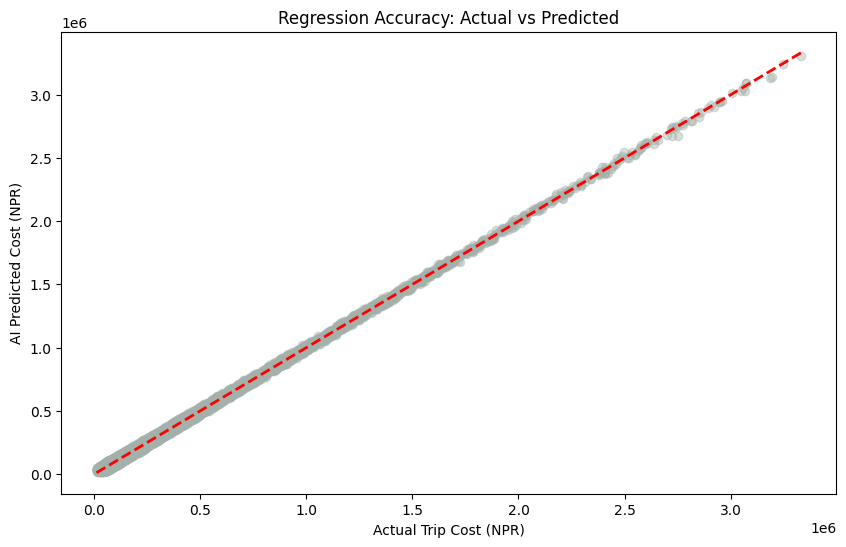

In [39]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='#A3B1AA') # Using your Sage Green
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
plt.xlabel('Actual Trip Cost (NPR)')
plt.ylabel('AI Predicted Cost (NPR)')
plt.title('Regression Accuracy: Actual vs Predicted')
plt.show()

# Visualizing the "Residuals" (The Error Plot)

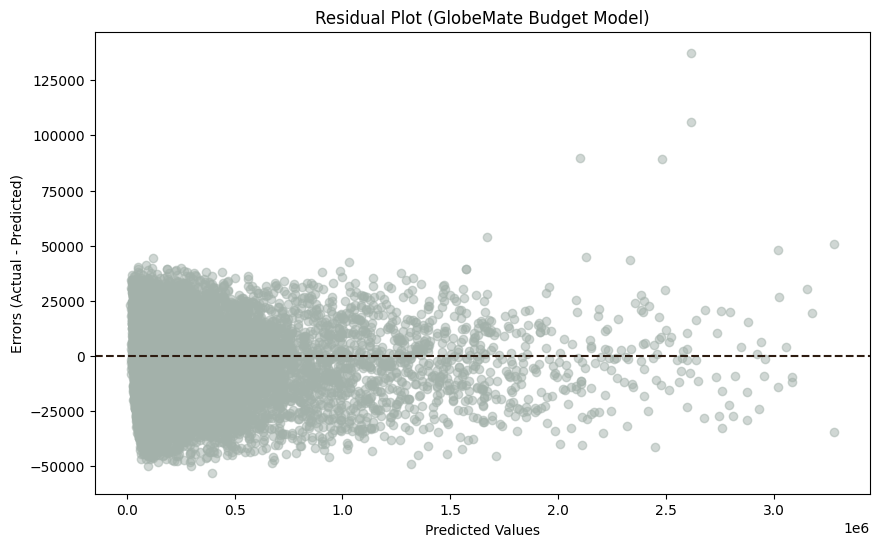

In [40]:
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color='#A3B1AA')
plt.axhline(y=0, color='#2D1B10', linestyle='--')
plt.title('Residual Plot (GlobeMate Budget Model)')
plt.xlabel('Predicted Values')
plt.ylabel('Errors (Actual - Predicted)')
plt.show()

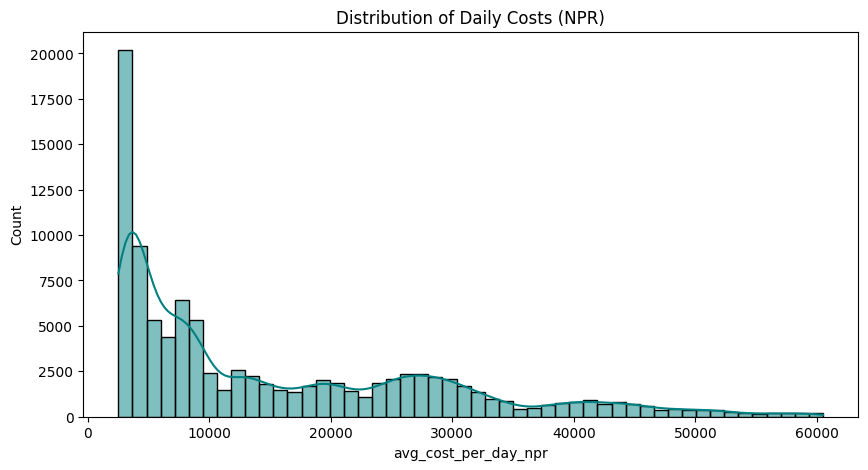

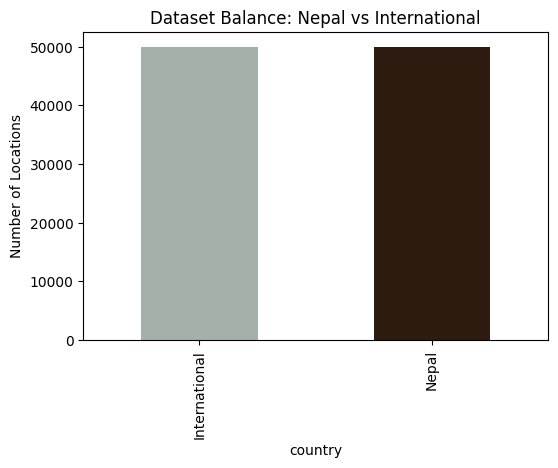

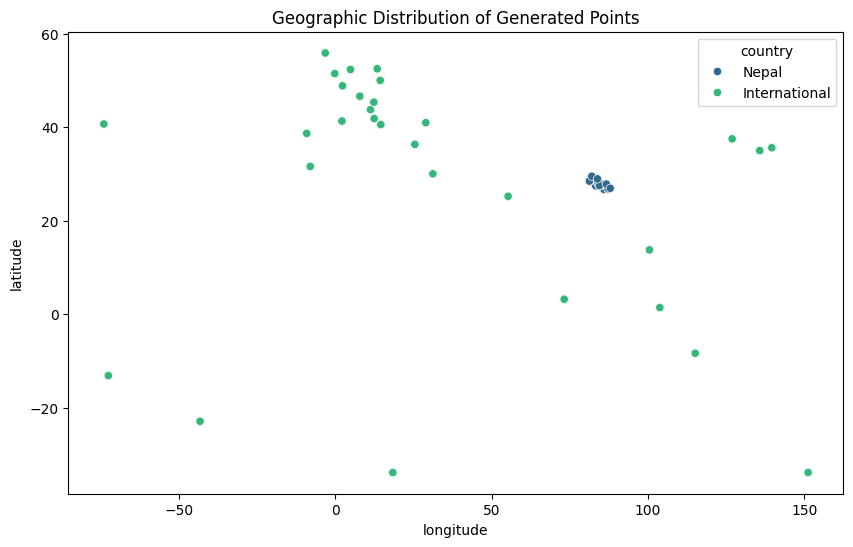

In [41]:
# 1. Distribution of Costs
plt.figure(figsize=(10, 5))
sns.histplot(df['avg_cost_per_day_npr'], bins=50, kde=True, color='teal')
plt.title('Distribution of Daily Costs (NPR)')
plt.show()

# 2. Nepal vs International Count
plt.figure(figsize=(6, 4))
df['country'].value_counts().plot(kind='bar', color=['#A3B1AA', '#2D1B10'])
plt.title('Dataset Balance: Nepal vs International')
plt.ylabel('Number of Locations')
plt.show()

# 3. Geo-Spatial Clustering (Sample of 1000 rows for speed)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(1000), x='longitude', y='latitude', hue='country', palette='viridis')
plt.title('Geographic Distribution of Generated Points')
plt.show()

In [42]:
# 1. Save the NLP Vectorizer
joblib.dump(tfidf, 'vibe_vectorizer.pkl')

# 2. Save the NLP Matrix
joblib.dump(vibe_matrix, 'vibe_matrix.pkl')

# 3. Save the Budget Regression Model
joblib.dump(budget_model, 'budget_model.pkl')

# 4. Save the Cleaned Dataframe (as a pickle for speed)
df.to_pickle('destination_data.pkl')

print(" ALL SYSTEMS SAVED. Ready for production deployment.")

 ALL SYSTEMS SAVED. Ready for production deployment.


In [47]:
import sklearn
print(sklearn.__version__)

1.7.2


In [45]:
%pip install -U scikit-learn

  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl (8.0 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.2
    Uninstalling scikit-learn-1.7.2:
      Successfully uninstalled scikit-learn-1.7.2
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
import sklearn
print(sklearn.__version__)

1.7.2
